In [1]:
import os
import subprocess

# Add texlive to PATH
texlive_path = "/sw/andes/spack-envs/base/opt/linux-rhel8-x86_64/gcc-8.3.1/texlive-20210325-ari2ztcowrqldrwjblfqpdiphkzd3nhu/bin/x86_64-linux"
os.environ['PATH'] = f"{texlive_path}:{os.environ['PATH']}"

# Verify latex is available
try:
    result = subprocess.run(['which', 'latex'], capture_output=True, text=True)
    print(f"LaTeX found at: {result.stdout.strip()}")
except:
    print("Warning: LaTeX not found in PATH")

LaTeX found at: /sw/andes/spack-envs/base/opt/linux-rhel8-x86_64/gcc-8.3.1/texlive-20210325-ari2ztcowrqldrwjblfqpdiphkzd3nhu/bin/x86_64-linux/latex


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import cmasher as cmr


import matplotlib
matplotlib.rc('font', family='serif', size=12)
matplotlib.rcParams['xtick.direction'] = 'out'
matplotlib.rcParams['ytick.direction'] = 'out'
matplotlib.rcParams['xtick.top'] = True
matplotlib.rcParams['ytick.right'] = True
matplotlib.rcParams['xtick.minor.visible'] = True
matplotlib.rcParams['ytick.minor.visible'] = True
matplotlib.rcParams['lines.dash_capstyle'] = 'round'
matplotlib.rcParams['figure.dpi'] = 200
matplotlib.rcParams['text.usetex'] = True

In [3]:
beta = 25
B0 = np.sqrt(2/beta)
Nres = 10240
def load_data(data_file):
    data = np.load(data_file, allow_pickle=True)

    hist_mag = data['hist_mag']
    mag_channels = data['mag_channels']

    hist_other = data['hist_other']
    other_channels = data['other_channels']

    ell_bin_edges = data['ell_bin_edges']
    theta_bin_edges = data['theta_bin_edges']
    phi_bin_edges = data['phi_bin_edges']
    sf_bin_edges = data['sf_bin_edges']
    product_bin_edges = data['product_bin_edges']

    print("sf_bin_edges", np.min(sf_bin_edges), np.max(sf_bin_edges), len(sf_bin_edges))
    print("product_bin_edges", np.min(product_bin_edges), np.max(product_bin_edges), len(product_bin_edges))


    ell_bin_centers = 0.5*(ell_bin_edges[1:] + ell_bin_edges[:-1])
    theta_bin_centers = 0.5*(theta_bin_edges[1:] + theta_bin_edges[:-1])
    phi_bin_centers = 0.5*(phi_bin_edges[1:] + phi_bin_edges[:-1])
    sf_bin_centers = 0.5*(sf_bin_edges[1:] + sf_bin_edges[:-1])
    product_bin_centers = 0.5*(product_bin_edges[1:] + product_bin_edges[:-1])

    ell = ell_bin_centers/Nres
    dB  = (sf_bin_centers/np.sqrt(2))
    hist = np.sum(hist_mag[1], axis=(1,2)).T/np.sum(np.sum(hist_mag[1], axis=(1,2)).T,axis=0)
    bsf_median = np.array([ np.interp(0.5, np.cumsum(np.sum(hist_mag[1], axis=(1,2))[i]) / np.sum(hist_mag[1], axis=(1,2,3))[i], (sf_bin_centers/np.sqrt(2))) for i in range(hist_mag[1].shape[0])])

    return ell, dB, hist, bsf_median


In [4]:
data_file = "/lustre/orion/ast207/proj-shared/dfielding/Production_plm/sfunctor_results/results_Turb_10240_beta25_dedt025_plm/ndisp10000_nrand1000_nell128_sw2_job3039703/sf_results_all_slices.npz"
ell_H, dB_H, hist_H, bsf_median_H = load_data(data_file)

data_file = "/lustre/orion/ast207/proj-shared/dfielding/Production_plm/sfunctor_results/results_Turb_2560_beta25_dedt025_plm/ndisp3000_nrand10000_nell128_sw2_job3039926/sf_results_all_slices.npz"
ell_M, dB_M, hist_M, bsf_median_M = load_data(data_file)

data_file = "/lustre/orion/ast207/proj-shared/dfielding/Production_plm/sfunctor_results/results_Turb_640_beta25_dedt025_plm/ndisp10000_nrand10000_nell128_sw2_job3039955/sf_results_all_slices.npz"
ell_L, dB_L, hist_L, bsf_median_L = load_data(data_file)

sf_bin_edges 1e-05 100000.0 101
product_bin_edges 1e-05 100000.0 101
sf_bin_edges 1e-05 10.0 201
product_bin_edges 1e-08 100000.0 201
sf_bin_edges 1e-05 10.0 201
product_bin_edges 1e-08 100000.0 201


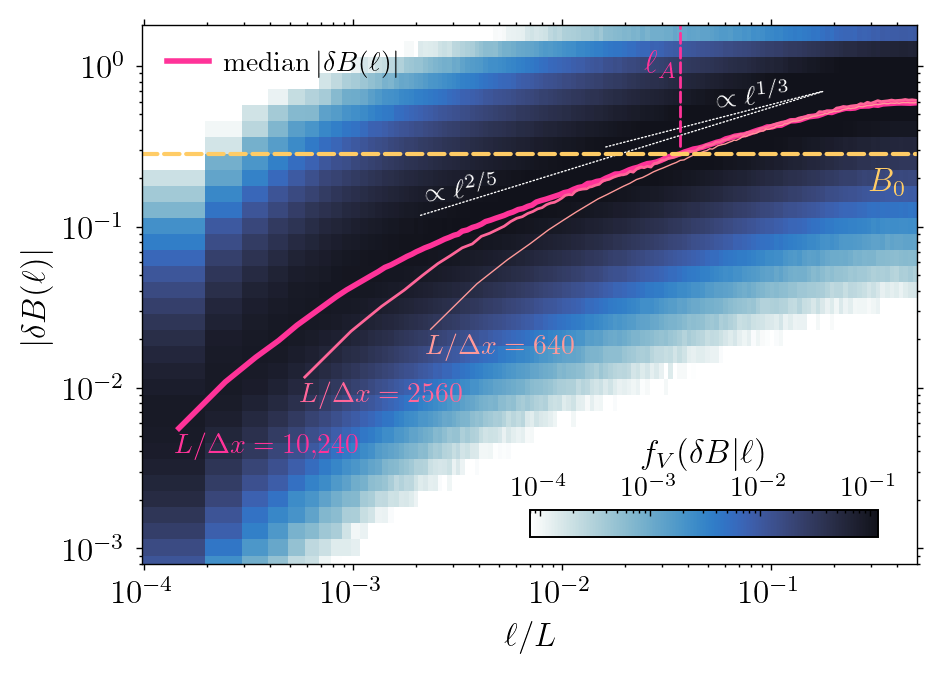

In [32]:
median_color = '#ff3399'
median_color_M = '#ff6699'
median_color_L = '#ff9999'
B0_color = '#ffcc66'

fig, ax = plt.subplots(1, 1, figsize=(5, 3.5))
plot = ax.pcolormesh(
    ell_H,
    dB_H,
    hist_H,
    norm=LogNorm(0.8e-4, 1.2e-1),
    cmap=cmr.get_sub_cmap('cmr.arctic_r',0, 0.9),
    zorder=-1,
    rasterized=True
)

# Make axis spines thinner
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

# Make major and minor ticks thinner
ax.tick_params(axis='both', which='both', width=0.5, length=2)
ax.tick_params(axis='both', which='minor', width=0.5, length=1)

# Create inset axes for horizontal colorbar in lower right corner
# Position: [left, bottom, width, height] in axes coordinates
# 40% width (0.4) and 5% height (0.05) in lower right
inset_axes = ax.inset_axes([0.5, 0.05, 0.45, 0.05])
cb = fig.colorbar(plot, cax=inset_axes, orientation='horizontal')
cb.set_label(r"$f_V(\delta B|\ell)$", labelpad=5)
cb.ax.xaxis.set_label_position('top')
cb.ax.xaxis.tick_top()
cb.ax.xaxis.set_ticks_position('top')
cb.ax.tick_params(axis='x', labelsize=10, width=0.5, length=2, direction='in', which='major')
cb.ax.tick_params(axis='x', width=0.5, length=1, direction='in', which='minor')

# Make colorbar outline thinner
for spine in cb.ax.spines.values():
    spine.set_linewidth(0.7)

ax.loglog(ell_H, bsf_median_H, color=median_color, lw=2, label = r"${\rm median} \, |\delta B(\ell)|$")
ax.loglog(ell_M*4, bsf_median_M, color=median_color_M, lw=1)
ax.loglog(ell_L*16, bsf_median_L, color=median_color_L, lw=0.5)

ax.text(
    ell_H[0]/1.05, bsf_median_H[0]/1.05, r"$L/\Delta x = 10{,}240$",
    color=median_color, ha='left', va='top',
    rotation=0, rotation_mode='anchor', fontsize=10
)
ax.text(
    ell_M[0]*4/1.05, bsf_median_M[0]/1.05, r"$L/\Delta x = 2560$",
    color=median_color_M, ha='left', va='top',
    rotation=0, rotation_mode='anchor', fontsize=10
)
ax.text(
    ell_L[0]*16/1.05, bsf_median_L[0]/1.05, r"$L/\Delta x = 640$",
    color=median_color_L, ha='left', va='top',
    rotation=0, rotation_mode='anchor', fontsize=10
)

# plot 2/5 power law line
line_color = 'white'
x_line = ell_H[20:-20]
y_line = 2.5 * B0 * (x_line / (ell_H[-20])) ** (2/5)
ax.loglog(x_line, y_line, color=line_color, lw=0.5, ls=':')

# Compute midpoint and angle for label
mid = 1*len(x_line) // 9
x_mid, y_mid = x_line[mid], y_line[mid] * 1.18
pt1, pt2 = [x_line[0], y_line[0]], [x_line[-1], y_line[-1]]
angle = np.degrees(np.arctan2(*(ax.transData.transform(pt2) - ax.transData.transform(pt1))[::-1]))

ax.text(
    x_mid, y_mid, r"$\propto \ell^{2/5}$",
    color=line_color, va='center', ha='center', fontsize=10,
    rotation=angle, rotation_mode='anchor'
)

# plot 1/3 power law line
line_color = 'white'
x_line = ell_H[60:-20]
y_line = 2.5 * B0 * (x_line / (ell_H[-20])) ** (1/3)
ax.loglog(x_line, y_line, color=line_color, lw=0.5, ls=':')

# Compute midpoint and angle for label
mid = 4*len(x_line) // 6
x_mid, y_mid = x_line[mid], y_line[mid] * 1.18
pt1, pt2 = [x_line[0], y_line[0]], [x_line[-1], y_line[-1]]
angle = np.degrees(np.arctan2(*(ax.transData.transform(pt2) - ax.transData.transform(pt1))[::-1]))

ax.text(
    x_mid, y_mid, r"$\propto \ell^{1/3}$",
    color=line_color, va='center', ha='center', fontsize=10,
    rotation=angle, rotation_mode='anchor'
)

# plot B0 line
ax.axhline(B0, color=B0_color, linestyle='--')
# Add label 5% from the left edge above the line
ax.text(ell_H[-1]*0.9, B0/1.2, r"$B_0$", color=B0_color, va='top', ha='right', fontsize=12)


# add short vertical lines to indicate where bsfp[2] and bsf_median cross B0
x_cross = ell_H[np.argmin(np.abs(bsf_median_H - B0))]
ax.axvline(x_cross, color=median_color, linestyle='--', lw=1, ymin=0.775, ymax=1.0)
# Add label above the top of the line, at y=0.3 in axes coordinates
ax.text(
    x_cross/1.05, 0.9,  # y in axes coordinates
    r"$\ell_{A}$",
    color=median_color, ha='right', va='bottom', fontsize=12,
    transform=ax.get_xaxis_transform()  # x in data, y in axes
)


# ax.set_ylabel(r'$|\delta B^{(2pt)}(\ell)| \doteq \frac{|\mathbf{B}(x{+}\ell) {-} \mathbf{B}(x)|}{\sqrt{2}}$')#, loc='top')
ax.set_ylabel(r'$|\delta B (\ell)|$')#, loc='top')
ax.set_xlabel(r'$\ell / L$')
ax.set_ylim(8e-4, 1.8)
ax.legend(
    loc='upper left',
    fontsize=10,
    frameon=False,
    handlelength=1.5,      # make handle length smaller
    handletextpad=0.5      # make space between handle and text smaller
    # bbox_to_anchor=(1, 0.1)
)



fig.savefig("bsf_median_comparison.pdf", dpi=300, bbox_inches='tight')

# ax.text(
#     0.02, 0.98,
#     r"$\delta B / B_0 = 2$"+"\n"+r"$L/\Delta x = 10{,}240$",
#     transform=ax.transAxes,
#     va='top',
#     ha='left',
#     fontsize=11,
#     color='black'
# )


In [53]:
# data_file = "/lustre/orion/ast207/proj-shared/dfielding/Production_plm/sfunctor_results/results_Turb_2560_beta25_dedt025_plm/ndisp10000_nrand1000_nell128_sw3_job3039675/sf_results_all_slices.npz"
data_file = "/lustre/orion/ast207/proj-shared/dfielding/Production_plm/sfunctor_results/results_Turb_10240_beta25_dedt025_plm/ndisp10000_nrand1000_nell128_sw2_job3039703/sf_results_Turb_10240_beta25_dedt025_plm_axis1_slice0p125_file0011.npz"
# data_file = "/lustre/orion/ast207/proj-shared/dfielding/Production_plm/sfunctor_results/results_Turb_640_beta25_dedt025_plm/ndisp2000_nrand400_nell128_sw2_job3039915/sf_results_all_slices.npz"

beta = 25
B0 = np.sqrt(2/beta)

data = np.load(data_file, allow_pickle=True)

hist_mag = data['hist_mag']
mag_channels = data['mag_channels']

hist_other = data['hist_other']
other_channels = data['other_channels']

ell_bin_edges = data['ell_bin_edges']
theta_bin_edges = data['theta_bin_edges']
phi_bin_edges = data['phi_bin_edges']
sf_bin_edges = data['sf_bin_edges']
# sf_derivative_bin_edges = data['sf_derivative_bin_edges']
product_bin_edges = data['product_bin_edges']

print("sf_bin_edges", np.min(sf_bin_edges), np.max(sf_bin_edges), len(sf_bin_edges))
print("sf_derivative_bin_edges", np.min(sf_derivative_bin_edges), np.max(sf_derivative_bin_edges), len(sf_derivative_bin_edges))
print("product_bin_edges", np.min(product_bin_edges), np.max(product_bin_edges), len(product_bin_edges))

sf_bin_edges 1e-05 100000.0 101
sf_derivative_bin_edges 0.01 100000.0 201
product_bin_edges 1e-05 100000.0 101


In [4]:
mag_channels

array(['D_V', 'D_B', 'D_RHO', 'D_VA', 'D_ZPLUS', 'D_ZMINUS', 'D_OMEGA',
       'D_J', 'D_CURV', 'D_GRAD_RHO'], dtype='<U10')

In [5]:
other_channels

array(['D_Vperp_CROSS_Bperp', 'D_Vperp_CROSS_VAperp',
       'D_Vperp_CROSS_Omegaperp', 'D_Bperp_CROSS_Jperp',
       'D_Vperp_D_Bperp_MAG', 'D_Vperp_D_VAperp_MAG',
       'D_Vperp_D_Omegaperp_MAG', 'D_Bperp_D_Jperp_MAG', 'D_V_CROSS_B',
       'D_V_CROSS_VA', 'D_V_CROSS_OMEGA', 'D_B_CROSS_J', 'D_V_D_B_MAG',
       'D_V_D_VA_MAG', 'D_V_D_OMEGA_MAG', 'D_B_D_J_MAG',
       'D_CURV_CROSS_GRAD_RHO', 'D_CURV_D_GRAD_RHO_MAG'], dtype='<U23')

In [55]:
ell_bin_centers = 0.5*(ell_bin_edges[1:] + ell_bin_edges[:-1])
theta_bin_centers = 0.5*(theta_bin_edges[1:] + theta_bin_edges[:-1])
phi_bin_centers = 0.5*(phi_bin_edges[1:] + phi_bin_edges[:-1])
sf_bin_centers = 0.5*(sf_bin_edges[1:] + sf_bin_edges[:-1])
sf_derivative_bin_centers = 0.5*(sf_derivative_bin_edges[1:] + sf_derivative_bin_edges[:-1])
product_bin_centers = 0.5*(product_bin_edges[1:] + product_bin_edges[:-1])

In [11]:
hist_mag.shape

(10, 128, 18, 18, 100)

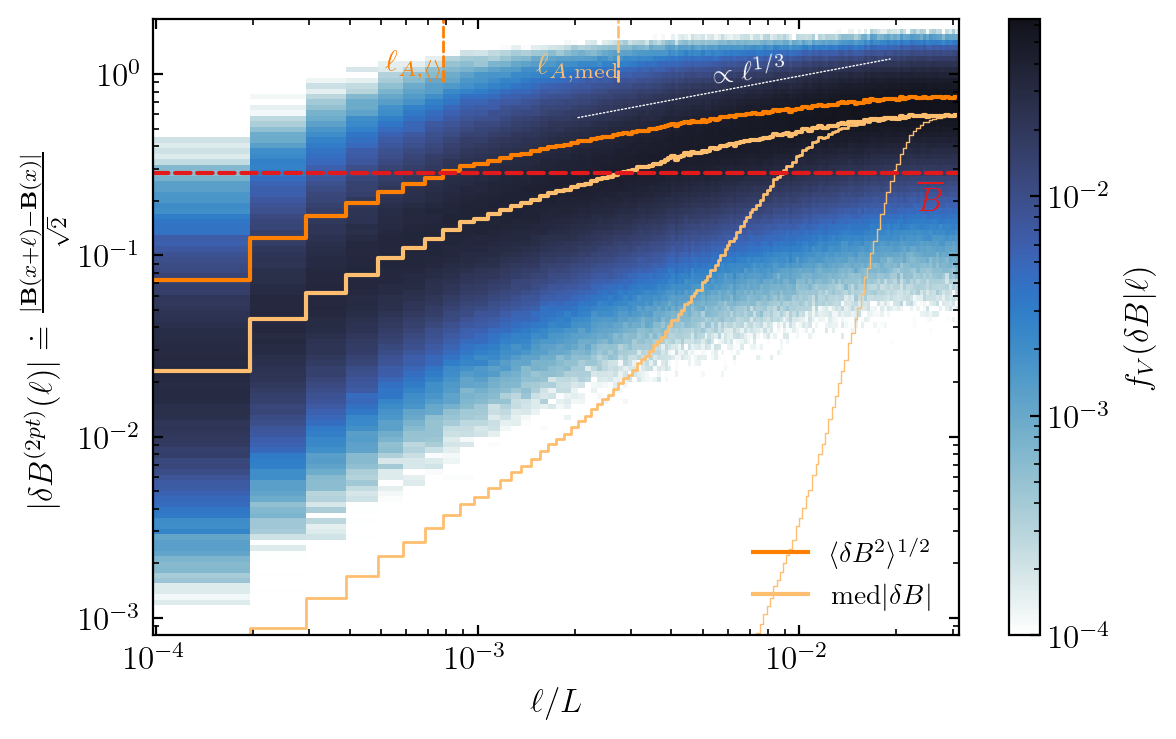

In [41]:
Nres = 10240

p_orders = np.arange(1,11,1)
bsfp = np.array([ (np.sum(np.sum(hist_mag[1], axis=(1,2))*(sf_bin_centers/np.sqrt(2))**p, axis=1) / np.sum(hist_mag[1], axis=(1,2,3)))**(1/p) for p in p_orders])
bsf_median = np.array([ np.interp(0.5, np.cumsum(np.sum(hist_mag[1], axis=(1,2))[i]) / np.sum(hist_mag[1], axis=(1,2,3))[i], (sf_bin_centers/np.sqrt(2))) for i in range(hist_mag[1].shape[0])])



fig, ax = plt.subplots(1, 1, figsize=(6.5, 4))
plot = ax.pcolormesh(
    ell_bin_centers/Nres,
    (sf_bin_centers/np.sqrt(2)),
    np.sum(hist_mag[1], axis=(1,2)).T/np.sum(np.sum(hist_mag[1], axis=(1,2)).T,axis=0),
    norm=LogNorm(vmin = 1e-4),
    cmap=cmr.get_sub_cmap('cmr.arctic_r',0, 0.9)
)
cb = fig.colorbar(plot)
cb.set_label(r"$f_V(\delta B|\ell)$")
ax.step(ell_bin_edges[:-1]/Nres, bsfp[2], color='#ff7f00', where='post', label=r"$\langle \delta B^2 \rangle^{1/2}$" )#label = r"$\langle |\delta B^{(2pt)}(\ell)|^{2} \rangle^{1/2}$")
ax.step(ell_bin_edges[:-1]/Nres, bsf_median, color='#fdbf6f', where='post', label = r"${\rm med} |\delta B|$")#r"${\rm median}|\delta B^{(2pt)}(\ell)|$")

# add fake low res data 
ax.step(ell_bin_edges[:-1]/Nres, bsf_median*0.5*(1+np.tanh((ell_bin_edges[:-1]-80)/40)), color='#fdbf6f', where='post', lw=1)#r"${\rm median}|\delta B^{(2pt)}(\ell)|$")
ax.step(ell_bin_edges[:-1]/Nres, bsf_median*0.5*(1+np.tanh((ell_bin_edges[:-1]-200)/40)), color='#fdbf6f', where='post', lw=0.5)#r"${\rm median}|\delta B^{(2pt)}(\ell)|$")



# plot 1/3 power law line
line_color = 'white'
x_line = ell_bin_edges[:-1][20:-20]/Nres
y_line = 5 * B0 * (x_line / (ell_bin_edges[-2]/Nres)) ** (1/3)
ax.loglog(x_line, y_line, color=line_color, lw=0.5, ls=':')

# Compute midpoint and angle for label
mid = len(x_line) // 2
x_mid, y_mid = x_line[mid], y_line[mid] * 1.18
pt1, pt2 = [x_line[0], y_line[0]], [x_line[-1], y_line[-1]]
angle = np.degrees(np.arctan2(*(ax.transData.transform(pt2) - ax.transData.transform(pt1))[::-1]))

ax.text(
    x_mid, y_mid, r"$\propto \ell^{1/3}$",
    color=line_color, va='center', ha='center', fontsize=10,
    rotation=angle, rotation_mode='anchor'
)


# plot B0 line
ax.axhline(B0, color='#e31a1c', linestyle='--')
# Add label 5% from the left edge above the line
ax.text(ell_bin_edges[-1]*0.9/Nres, B0/1.2, r"$\overline{B}$", color='#e31a1c', va='top', ha='right', fontsize=12)


# add short vertical lines to indicate where bsfp[2] and bsf_median cross B0
x_cross = ell_bin_edges[np.argmin(np.abs(bsfp[2] - B0))]/Nres
ax.axvline(x_cross, color='#ff7f00', linestyle='--', lw=1, ymin=0.9, ymax=1.0)
# Add label above the top of the line, at y=0.3 in axes coordinates
ax.text(
    x_cross, 0.9,  # y in axes coordinates
    r"$\ell_{A, \langle \rangle}$",
    color='#ff7f00', ha='right', va='bottom', fontsize=11,
    transform=ax.get_xaxis_transform()  # x in data, y in axes
)
x_cross = ell_bin_edges[np.argmin(np.abs(bsf_median - B0))]/Nres
ax.axvline(x_cross, color='#fdbf6f', linestyle='--', lw=1, ymin=0.9, ymax=1.0)
# Add label above the top of the line, at y=0.3 in axes coordinates
ax.text(
    x_cross, 0.9,  # y in axes coordinates
    r"$\ell_{A, {\rm med}}$",
    color='#fdbf6f', ha='right', va='bottom', fontsize=11,
    transform=ax.get_xaxis_transform()  # x in data, y in axes
)


ax.set_ylabel(r'$|\delta B^{(2pt)}(\ell)| \doteq \frac{|\mathbf{B}(x{+}\ell) {-} \mathbf{B}(x)|}{\sqrt{2}}$')#, loc='top')
ax.set_xlabel(r'$\ell / L$')
ax.set_ylim(8e-4, 2)
ax.legend(
    loc='lower right',
    fontsize=10,
    frameon=False,
    # bbox_to_anchor=(1, 0.1)
)

# ax.text(
#     0.02, 0.98,
#     r"$\delta B / B_0 = 2$"+"\n"+r"$L/\Delta x = 10{,}240$",
#     transform=ax.transAxes,
#     va='top',
#     ha='left',
#     fontsize=11,
#     color='black'
# )


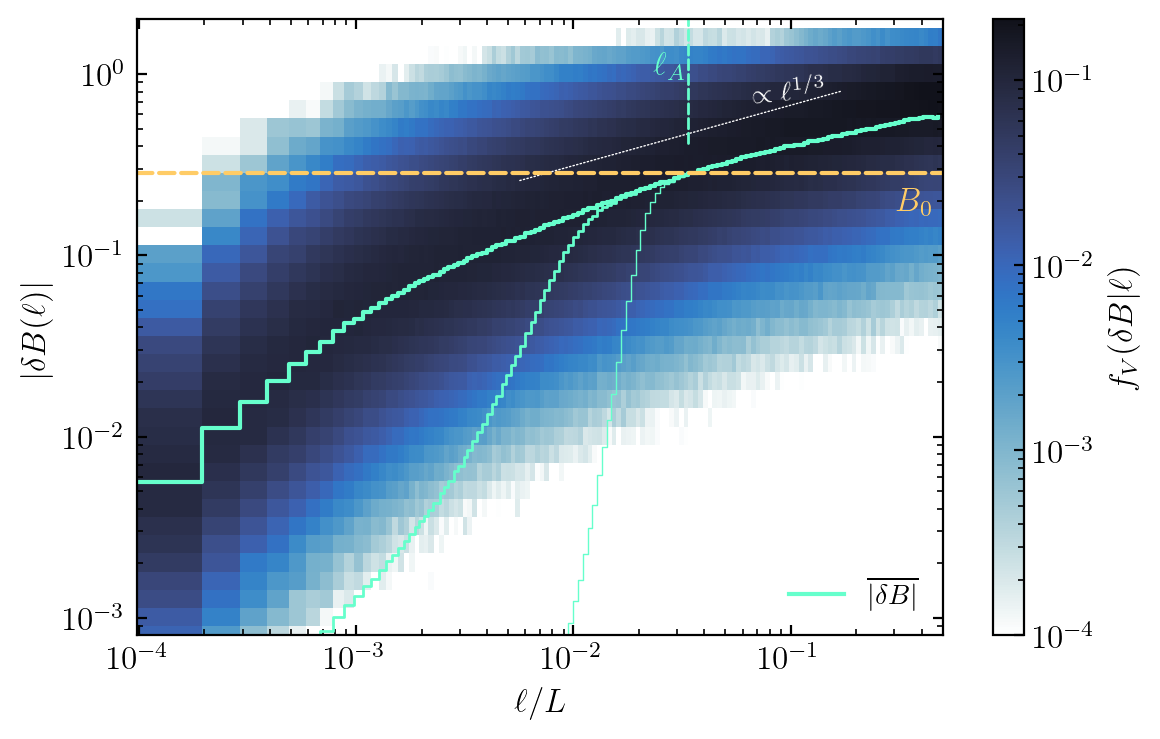

In [71]:
median_color = '#66ffcc'
B0_color = '#ffcc66'


Nres = 10240

p_orders = np.arange(1,11,1)
bsfp = np.array([ (np.sum(np.sum(hist_mag[1], axis=(1,2))*(sf_bin_centers/np.sqrt(2))**p, axis=1) / np.sum(hist_mag[1], axis=(1,2,3)))**(1/p) for p in p_orders])
bsf_median = np.array([ np.interp(0.5, np.cumsum(np.sum(hist_mag[1], axis=(1,2))[i]) / np.sum(hist_mag[1], axis=(1,2,3))[i], (sf_bin_centers/np.sqrt(2))) for i in range(hist_mag[1].shape[0])])

fig, ax = plt.subplots(1, 1, figsize=(6.5, 4))
plot = ax.pcolormesh(
    ell_bin_centers/Nres,
    (sf_bin_centers/np.sqrt(2)),
    np.sum(hist_mag[1], axis=(1,2)).T/np.sum(np.sum(hist_mag[1], axis=(1,2)).T,axis=0),
    norm=LogNorm(vmin = 1e-4),
    cmap=cmr.get_sub_cmap('cmr.arctic_r',0, 0.9)
)
cb = fig.colorbar(plot)
cb.set_label(r"$f_V(\delta B|\ell)$")
ax.step(ell_bin_edges[:-1]/Nres, bsf_median, color=median_color, where='post', label = r"$\overline{|\delta B|}$")#r"${\rm median}|\delta B^{(2pt)}(\ell)|$")

# add fake low res data 
ax.step(ell_bin_edges[:-1]/Nres, bsf_median*0.5*(1+np.tanh((ell_bin_edges[:-1]-80)/40)), color=median_color, where='post', lw=1)#r"${\rm median}|\delta B^{(2pt)}(\ell)|$")
ax.step(ell_bin_edges[:-1]/Nres, bsf_median*0.5*(1+np.tanh((ell_bin_edges[:-1]-200)/40)), color=median_color, where='post', lw=0.5)#r"${\rm median}|\delta B^{(2pt)}(\ell)|$")


# plot 1/3 power law line
line_color = 'white'
x_line = ell_bin_edges[:-1][40:-20]/Nres
y_line = 4 * B0 * (x_line / (ell_bin_edges[-2]/Nres)) ** (1/3)
ax.loglog(x_line, y_line, color=line_color, lw=0.5, ls=':')

# Compute midpoint and angle for label
mid = 5*len(x_line) // 6
x_mid, y_mid = x_line[mid], y_line[mid] * 1.18
pt1, pt2 = [x_line[0], y_line[0]], [x_line[-1], y_line[-1]]
angle = np.degrees(np.arctan2(*(ax.transData.transform(pt2) - ax.transData.transform(pt1))[::-1]))

ax.text(
    x_mid, y_mid, r"$\propto \ell^{1/3}$",
    color=line_color, va='center', ha='center', fontsize=10,
    rotation=angle, rotation_mode='anchor'
)


# plot B0 line
ax.axhline(B0, color=B0_color, linestyle='--')
# Add label 5% from the left edge above the line
ax.text(ell_bin_edges[-1]*0.9/Nres, B0/1.2, r"$B_0$", color=B0_color, va='top', ha='right', fontsize=12)


# add short vertical lines to indicate where bsfp[2] and bsf_median cross B0
x_cross = ell_bin_edges[np.argmin(np.abs(bsf_median - B0))]/Nres
ax.axvline(x_cross, color=median_color, linestyle='--', lw=1, ymin=0.8, ymax=1.0)
# Add label above the top of the line, at y=0.3 in axes coordinates
ax.text(
    x_cross/1.05, 0.9,  # y in axes coordinates
    r"$\ell_{A}$",
    color=median_color, ha='right', va='bottom', fontsize=12,
    transform=ax.get_xaxis_transform()  # x in data, y in axes
)


# ax.set_ylabel(r'$|\delta B^{(2pt)}(\ell)| \doteq \frac{|\mathbf{B}(x{+}\ell) {-} \mathbf{B}(x)|}{\sqrt{2}}$')#, loc='top')
ax.set_ylabel(r'$|\delta B (\ell)|$')#, loc='top')
ax.set_xlabel(r'$\ell / L$')
ax.set_ylim(8e-4, 2)
ax.legend(
    loc='lower right',
    fontsize=10,
    frameon=False,
    # bbox_to_anchor=(1, 0.1)
)

# ax.text(
#     0.02, 0.98,
#     r"$\delta B / B_0 = 2$"+"\n"+r"$L/\Delta x = 10{,}240$",
#     transform=ax.transAxes,
#     va='top',
#     ha='left',
#     fontsize=11,
#     color='black'
# )


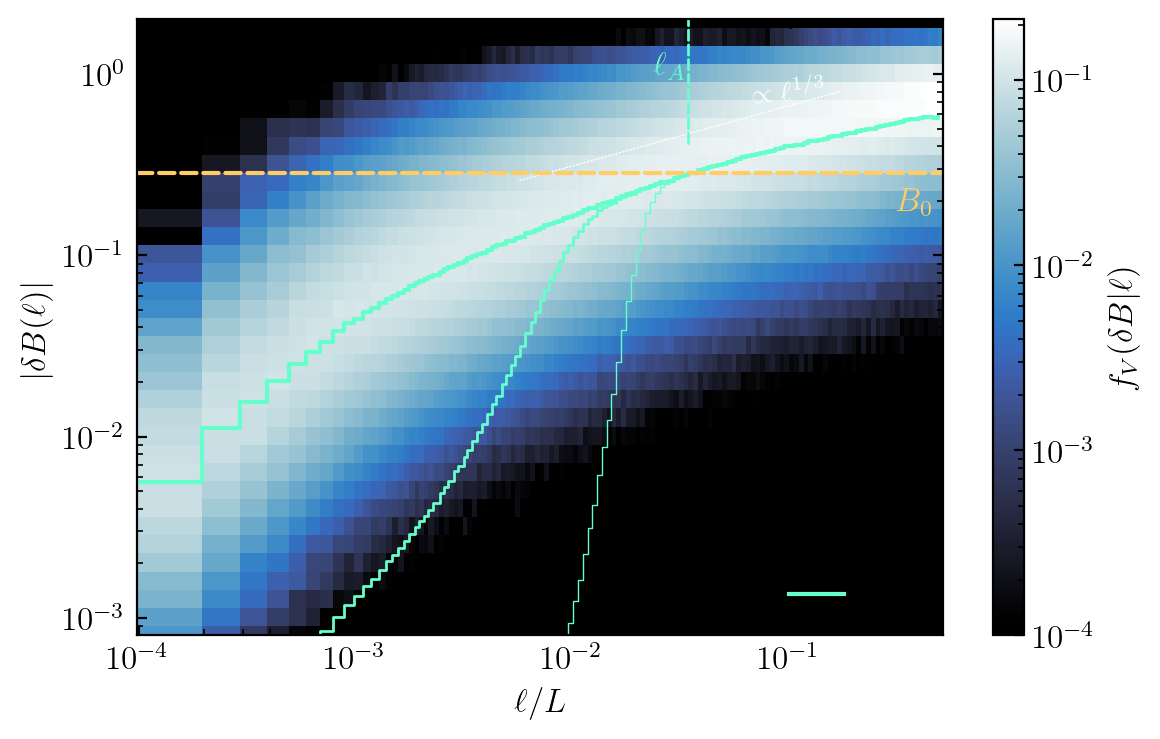

In [72]:
median_color = '#66ffcc'
B0_color = '#ffcc66'


Nres = 10240

p_orders = np.arange(1,11,1)
bsfp = np.array([ (np.sum(np.sum(hist_mag[1], axis=(1,2))*(sf_bin_centers/np.sqrt(2))**p, axis=1) / np.sum(hist_mag[1], axis=(1,2,3)))**(1/p) for p in p_orders])
bsf_median = np.array([ np.interp(0.5, np.cumsum(np.sum(hist_mag[1], axis=(1,2))[i]) / np.sum(hist_mag[1], axis=(1,2,3))[i], (sf_bin_centers/np.sqrt(2))) for i in range(hist_mag[1].shape[0])])

fig, ax = plt.subplots(1, 1, figsize=(6.5, 4))
ax.set_facecolor('black')
plot = ax.pcolormesh(
    ell_bin_centers/Nres,
    (sf_bin_centers/np.sqrt(2)),
    np.sum(hist_mag[1], axis=(1,2)).T/np.sum(np.sum(hist_mag[1], axis=(1,2)).T,axis=0),
    norm=LogNorm(vmin = 1e-4),
    cmap=cmr.get_sub_cmap('cmr.arctic',0, 1)
)
cb = fig.colorbar(plot)
cb.set_label(r"$f_V(\delta B|\ell)$")
ax.step(ell_bin_edges[:-1]/Nres, bsf_median, color=median_color, where='post', label = r"$\overline{|\delta B|}$")#r"${\rm median}|\delta B^{(2pt)}(\ell)|$")

# add fake low res data 
ax.step(ell_bin_edges[:-1]/Nres, bsf_median*0.5*(1+np.tanh((ell_bin_edges[:-1]-80)/40)), color=median_color, where='post', lw=1)#r"${\rm median}|\delta B^{(2pt)}(\ell)|$")
ax.step(ell_bin_edges[:-1]/Nres, bsf_median*0.5*(1+np.tanh((ell_bin_edges[:-1]-200)/40)), color=median_color, where='post', lw=0.5)#r"${\rm median}|\delta B^{(2pt)}(\ell)|$")


# plot 1/3 power law line
line_color = 'white'
x_line = ell_bin_edges[:-1][40:-20]/Nres
y_line = 4 * B0 * (x_line / (ell_bin_edges[-2]/Nres)) ** (1/3)
ax.loglog(x_line, y_line, color=line_color, lw=0.5, ls=':')

# Compute midpoint and angle for label
mid = 5*len(x_line) // 6
x_mid, y_mid = x_line[mid], y_line[mid] * 1.18
pt1, pt2 = [x_line[0], y_line[0]], [x_line[-1], y_line[-1]]
angle = np.degrees(np.arctan2(*(ax.transData.transform(pt2) - ax.transData.transform(pt1))[::-1]))

ax.text(
    x_mid, y_mid, r"$\propto \ell^{1/3}$",
    color=line_color, va='center', ha='center', fontsize=10,
    rotation=angle, rotation_mode='anchor'
)


# plot B0 line
ax.axhline(B0, color=B0_color, linestyle='--')
# Add label 5% from the left edge above the line
ax.text(ell_bin_edges[-1]*0.9/Nres, B0/1.2, r"$B_0$", color=B0_color, va='top', ha='right', fontsize=12)


# add short vertical lines to indicate where bsfp[2] and bsf_median cross B0
x_cross = ell_bin_edges[np.argmin(np.abs(bsf_median - B0))]/Nres
ax.axvline(x_cross, color=median_color, linestyle='--', lw=1, ymin=0.8, ymax=1.0)
# Add label above the top of the line, at y=0.3 in axes coordinates
ax.text(
    x_cross/1.05, 0.9,  # y in axes coordinates
    r"$\ell_{A}$",
    color=median_color, ha='right', va='bottom', fontsize=12,
    transform=ax.get_xaxis_transform()  # x in data, y in axes
)


# ax.set_ylabel(r'$|\delta B^{(2pt)}(\ell)| \doteq \frac{|\mathbf{B}(x{+}\ell) {-} \mathbf{B}(x)|}{\sqrt{2}}$')#, loc='top')
ax.set_ylabel(r'$|\delta B (\ell)|$')#, loc='top')
ax.set_xlabel(r'$\ell / L$')
ax.set_ylim(8e-4, 2)
ax.legend(
    loc='lower right',
    fontsize=10,
    frameon=False,
    # bbox_to_anchor=(1, 0.1)
)

# ax.text(
#     0.02, 0.98,
#     r"$\delta B / B_0 = 2$"+"\n"+r"$L/\Delta x = 10{,}240$",
#     transform=ax.transAxes,
#     va='top',
#     ha='left',
#     fontsize=11,
#     color='black'
# )


Text(0.02, 0.98, '$\\delta B / \\overline{B} = 2$\n$L/\\Delta x = 2560$')

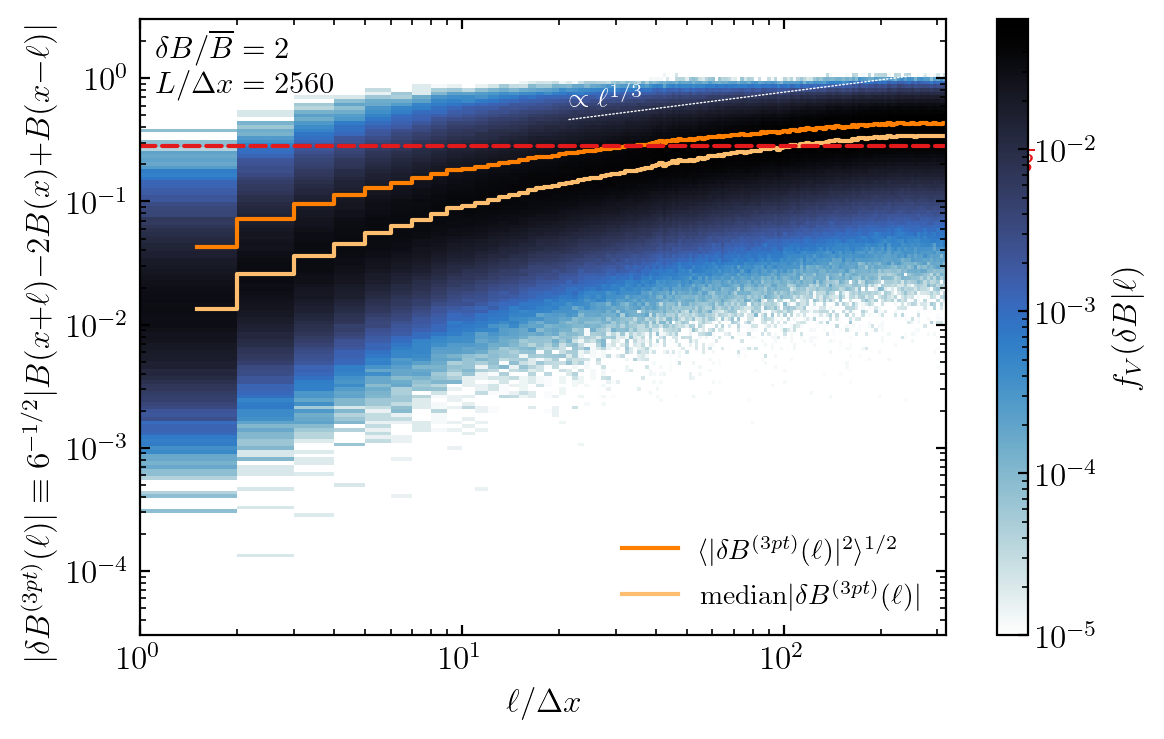

In [7]:
p_orders = np.arange(1,11,1)
bsfp = np.array([ (np.sum(np.sum(hist_mag[1], axis=(1,2))*(sf_bin_centers/np.sqrt(6))**p, axis=1) / np.sum(hist_mag[1], axis=(1,2,3)))**(1/p) for p in p_orders])
bsf_median = np.array([ np.interp(0.5, np.cumsum(np.sum(hist_mag[1], axis=(1,2))[i]) / np.sum(hist_mag[1], axis=(1,2,3))[i], (sf_bin_centers/np.sqrt(6))) for i in range(hist_mag[1].shape[0])])


fig, ax = plt.subplots(1, 1, figsize=(6.5, 4))
plot = ax.pcolormesh(ell_bin_centers, (sf_bin_centers/np.sqrt(6)), np.sum(hist_mag[1], axis=(1,2)).T/np.sum(np.sum(hist_mag[1], axis=(1,2)).T,axis=0), norm=LogNorm(vmin = 1e-5), cmap=cmr.arctic_r)
cb = fig.colorbar(plot)
cb.set_label(r"$f_V(\delta B|\ell)$")
ax.step(ell_bin_centers, bsfp[2], color='#ff7f00', where='mid', label = r"$\langle |\delta B^{(3pt)}(\ell)|^{2} \rangle^{1/2}$")
ax.step(ell_bin_centers, bsf_median, color='#fdbf6f', where='mid', label = r"${\rm median}|\delta B^{(3pt)}(\ell)|$")
# ax.grid(lw=0.5, ls=':')
ax.axhline(B0, color='#e31a1c', linestyle='--')
# Add label 5% from the left edge above the line
ax.text(600, B0/1.15, r"$\overline{B}$", color='#e31a1c', va='top', ha='right', fontsize=10)

line_color = 'white'
x_line = ell_bin_centers[20:]
y_line = 4*B0*(x_line/ell_bin_centers[-1])**(1/3)
ax.loglog(x_line, y_line, color=line_color, lw=0.5, ls=':')
# Add label just above the left edge of the line
ax.text(x_line[0], y_line[0]*1.15, r"$\propto \ell^{1/3}$", color=line_color, va='bottom', ha='left', fontsize=10)

ax.set_ylabel(r'$|\delta B^{(3pt)}(\ell)| \equiv 6^{-1/2}|B(x{+}\ell) {-} 2B(x) {+} B(x{-}\ell)|$', loc='top')
ax.set_xlabel(r'$\ell / \Delta x$')
ax.set_ylim(3e-5, 3)
ax.legend(loc='lower right', fontsize=10, frameon=False)

ax.text(
    0.02, 0.98,
    r"$\delta B / \overline{B} = 2$"+"\n"+r"$L/\Delta x = 2560$",
    transform=ax.transAxes,
    va='top',
    ha='left',
    fontsize=11,
    color='black'
)


Text(0.02, 0.98, '$\\delta B / \\overline{B} = 2$\n$L/\\Delta x = 2560$')

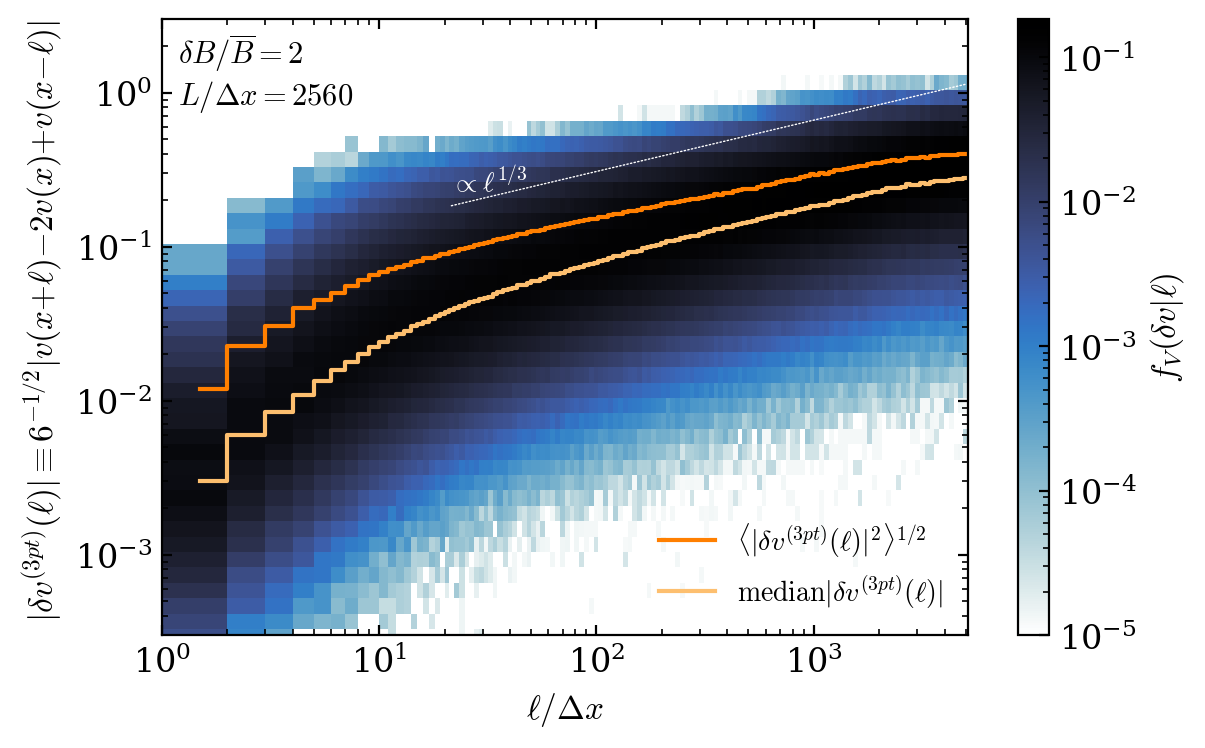

In [7]:
p_orders = np.arange(1,11,1)
vsfp = np.array([ (np.sum(np.sum(hist_mag[0], axis=(1,2))*(sf_bin_centers/np.sqrt(6))**p, axis=1) / np.sum(hist_mag[0], axis=(1,2,3)))**(1/p) for p in p_orders])
vsf_median = np.array([ np.interp(0.5, np.cumsum(np.sum(hist_mag[0], axis=(1,2))[i]) / np.sum(hist_mag[0], axis=(1,2,3))[i], (sf_bin_centers/np.sqrt(6))) for i in range(hist_mag[0].shape[0])])


fig, ax = plt.subplots(1, 1, figsize=(6.5, 4))
plot = ax.pcolormesh(ell_bin_centers, (sf_bin_centers/np.sqrt(6)), np.sum(hist_mag[0], axis=(1,2)).T/np.sum(np.sum(hist_mag[0], axis=(1,2)).T,axis=0), norm=LogNorm(vmin = 1e-5), cmap=cmr.arctic_r)
cb = fig.colorbar(plot)
cb.set_label(r"$f_V(\delta v|\ell)$")
ax.step(ell_bin_centers, vsfp[2], color='#ff7f00', where='mid', label = r"$\langle |\delta v^{(3pt)}(\ell)|^{2} \rangle^{1/2}$")
ax.step(ell_bin_centers, vsf_median, color='#fdbf6f', where='mid', label = r"${\rm median}|\delta v^{(3pt)}(\ell)|$")
# ax.grid(lw=0.5, ls=':')
# ax.axhline(1, color='#e31a1c', linestyle='--')
# ax.text(600, 1/1.15, r"$c_s$", color='#e31a1c', va='top', ha='right', fontsize=10)

line_color = 'white'
x_line = ell_bin_centers[20:]
y_line = 4*B0*(x_line/ell_bin_centers[-1])**(1/3)
ax.loglog(x_line, y_line, color=line_color, lw=0.5, ls=':')
# Add label just above the left edge of the line
ax.text(x_line[0], y_line[0]*1.15, r"$\propto \ell^{1/3}$", color=line_color, va='bottom', ha='left', fontsize=10)

ax.set_ylabel(r'$|\delta v^{(3pt)}(\ell)| \equiv 6^{-1/2}|v(x{+}\ell) {-} 2v(x) {+} v(x{-}\ell)|$', loc='top')
ax.set_xlabel(r'$\ell / \Delta x$')
ax.set_ylim(3e-4, 3)
ax.legend(loc='lower right', fontsize=10, frameon=False)

ax.text(
    0.02, 0.98,
    r"$\delta B / \overline{B} = 2$"+"\n"+r"$L/\Delta x = 2560$",
    transform=ax.transAxes,
    va='top',
    ha='left',
    fontsize=11,
    color='black'
)


Text(0.02, 0.98, '$\\delta B / \\overline{B} = 2$\n$L/\\Delta x = 2560$')

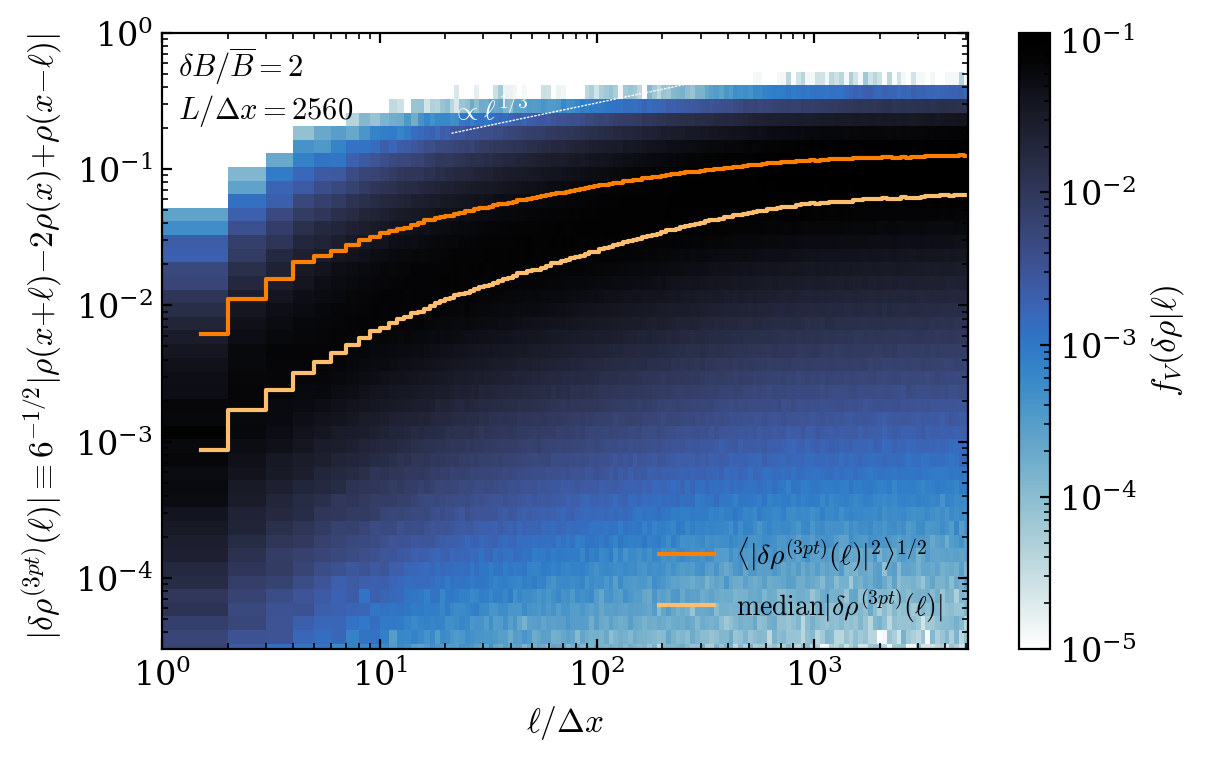

In [8]:
p_orders = np.arange(1,11,1)
rhosfp = np.array([ (np.sum(np.sum(hist_mag[2], axis=(1,2))*(sf_bin_centers/np.sqrt(6))**p, axis=1) / np.sum(hist_mag[2], axis=(1,2,3)))**(1/p) for p in p_orders])
rhosf_median = np.array([ np.interp(0.5, np.cumsum(np.sum(hist_mag[2], axis=(1,2))[i]) / np.sum(hist_mag[2], axis=(1,2,3))[i], (sf_bin_centers/np.sqrt(6))) for i in range(hist_mag[2].shape[0])])


fig, ax = plt.subplots(1, 1, figsize=(6.5, 4))
plot = ax.pcolormesh(ell_bin_centers, (sf_bin_centers/np.sqrt(6)), np.sum(hist_mag[2], axis=(1,2)).T/np.sum(np.sum(hist_mag[2], axis=(1,2)).T,axis=0), norm=LogNorm(vmin = 1e-5), cmap=cmr.arctic_r)
cb = fig.colorbar(plot)
cb.set_label(r"$f_V(\delta \rho|\ell)$")
ax.step(ell_bin_centers, rhosfp[2], color='#ff7f00', where='mid', label = r"$\langle |\delta \rho^{(3pt)}(\ell)|^{2} \rangle^{1/2}$")
ax.step(ell_bin_centers, rhosf_median, color='#fdbf6f', where='mid', label = r"${\rm median}|\delta \rho^{(3pt)}(\ell)|$")
# ax.grid(lw=0.5, ls=':')
# ax.axhline(1, color='#e31a1c', linestyle='--')
# ax.text(600, 1/1.15, r"$c_s$", color='#e31a1c', va='top', ha='right', fontsize=10)

line_color = 'white'
x_line = ell_bin_centers[20:]
y_line = 4*B0*(x_line/ell_bin_centers[-1])**(1/3)
ax.loglog(x_line, y_line, color=line_color, lw=0.5, ls=':')
# Add label just above the left edge of the line
ax.text(x_line[0], y_line[0]*1.15, r"$\propto \ell^{1/3}$", color=line_color, va='bottom', ha='left', fontsize=10)

ax.set_ylabel(r'$|\delta \rho^{(3pt)}(\ell)| \equiv 6^{-1/2}|\rho(x{+}\ell) {-} 2\rho(x) {+} \rho(x{-}\ell)|$', loc='top')
ax.set_xlabel(r'$\ell / \Delta x$')
ax.set_ylim(3e-5, 1)
ax.legend(loc='lower right', fontsize=10, frameon=False)

ax.text(
    0.02, 0.98,
    r"$\delta B / \overline{B} = 2$"+"\n"+r"$L/\Delta x = 2560$",
    transform=ax.transAxes,
    va='top',
    ha='left',
    fontsize=11,
    color='black'
)


Text(0.02, 0.98, '$\\delta B / \\overline{B} = 2$\n$L/\\Delta x = 2560$')

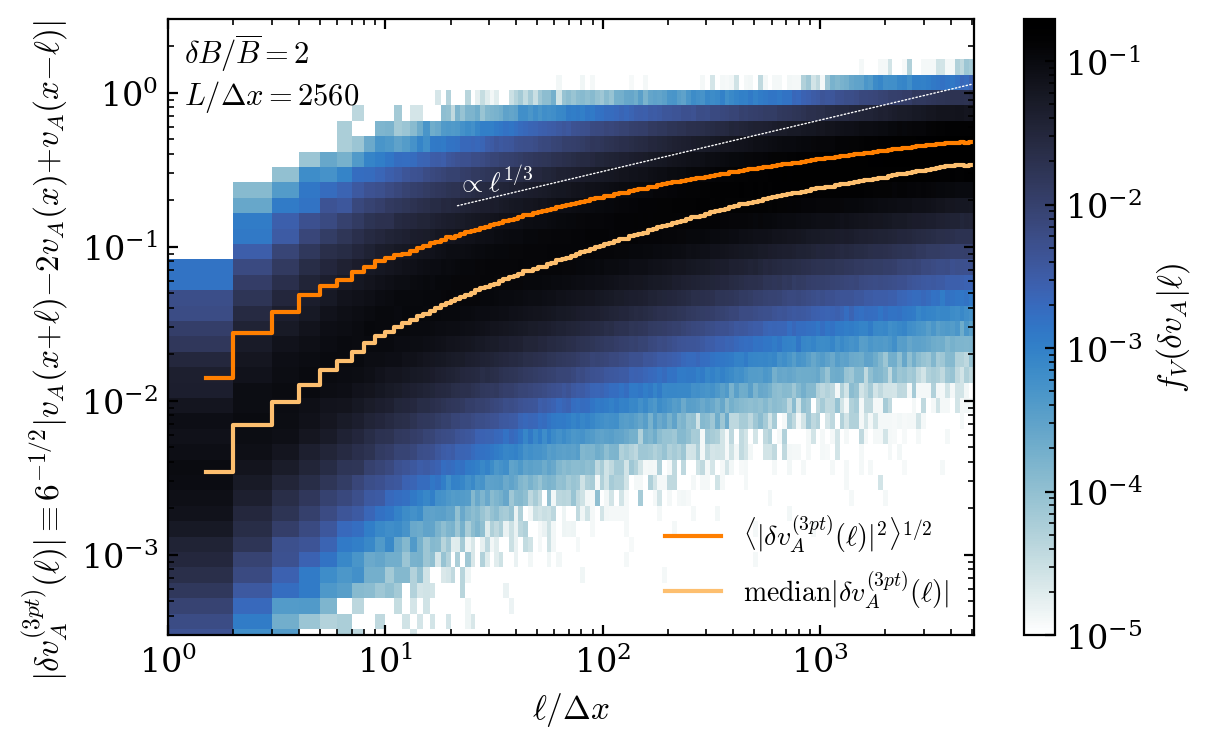

In [9]:
p_orders = np.arange(1,11,1)
rhosfp = np.array([ (np.sum(np.sum(hist_mag[3], axis=(1,2))*(sf_bin_centers/np.sqrt(6))**p, axis=1) / np.sum(hist_mag[3], axis=(1,2,3)))**(1/p) for p in p_orders])
rhosf_median = np.array([ np.interp(0.5, np.cumsum(np.sum(hist_mag[3], axis=(1,2))[i]) / np.sum(hist_mag[3], axis=(1,2,3))[i], (sf_bin_centers/np.sqrt(6))) for i in range(hist_mag[3].shape[0])])


fig, ax = plt.subplots(1, 1, figsize=(6.5, 4))
plot = ax.pcolormesh(ell_bin_centers, (sf_bin_centers/np.sqrt(6)), np.sum(hist_mag[3], axis=(1,2)).T/np.sum(np.sum(hist_mag[3], axis=(1,2)).T,axis=0), norm=LogNorm(vmin = 1e-5), cmap=cmr.arctic_r)
cb = fig.colorbar(plot)
cb.set_label(r"$f_V(\delta v_A|\ell)$")
ax.step(ell_bin_centers, rhosfp[2], color='#ff7f00', where='mid', label = r"$\langle |\delta v_A^{(3pt)}(\ell)|^{2} \rangle^{1/2}$")
ax.step(ell_bin_centers, rhosf_median, color='#fdbf6f', where='mid', label = r"${\rm median}|\delta v_A^{(3pt)}(\ell)|$")
# ax.grid(lw=0.5, ls=':')
# ax.axhline(1, color='#e31a1c', linestyle='--')
# ax.text(600, 1/1.15, r"$c_s$", color='#e31a1c', va='top', ha='right', fontsize=10)

line_color = 'white'
x_line = ell_bin_centers[20:]
y_line = 4*B0*(x_line/ell_bin_centers[-1])**(1/3)
ax.loglog(x_line, y_line, color=line_color, lw=0.5, ls=':')
# Add label just above the left edge of the line
ax.text(x_line[0], y_line[0]*1.15, r"$\propto \ell^{1/3}$", color=line_color, va='bottom', ha='left', fontsize=10)

ax.set_ylabel(r'$|\delta v_A^{(3pt)}(\ell)| \equiv 6^{-1/2}|v_A(x{+}\ell) {-} 2v_A(x) {+} v_A(x{-}\ell)|$', loc='top')
ax.set_xlabel(r'$\ell / \Delta x$')
ax.set_ylim(3e-4, 3)
ax.legend(loc='lower right', fontsize=10, frameon=False)

ax.text(
    0.02, 0.98,
    r"$\delta B / \overline{B} = 2$"+"\n"+r"$L/\Delta x = 2560$",
    transform=ax.transAxes,
    va='top',
    ha='left',
    fontsize=11,
    color='black'
)


Text(0.02, 0.98, '$\\delta B / \\overline{B} = 2$\n$L/\\Delta x = 2560$')

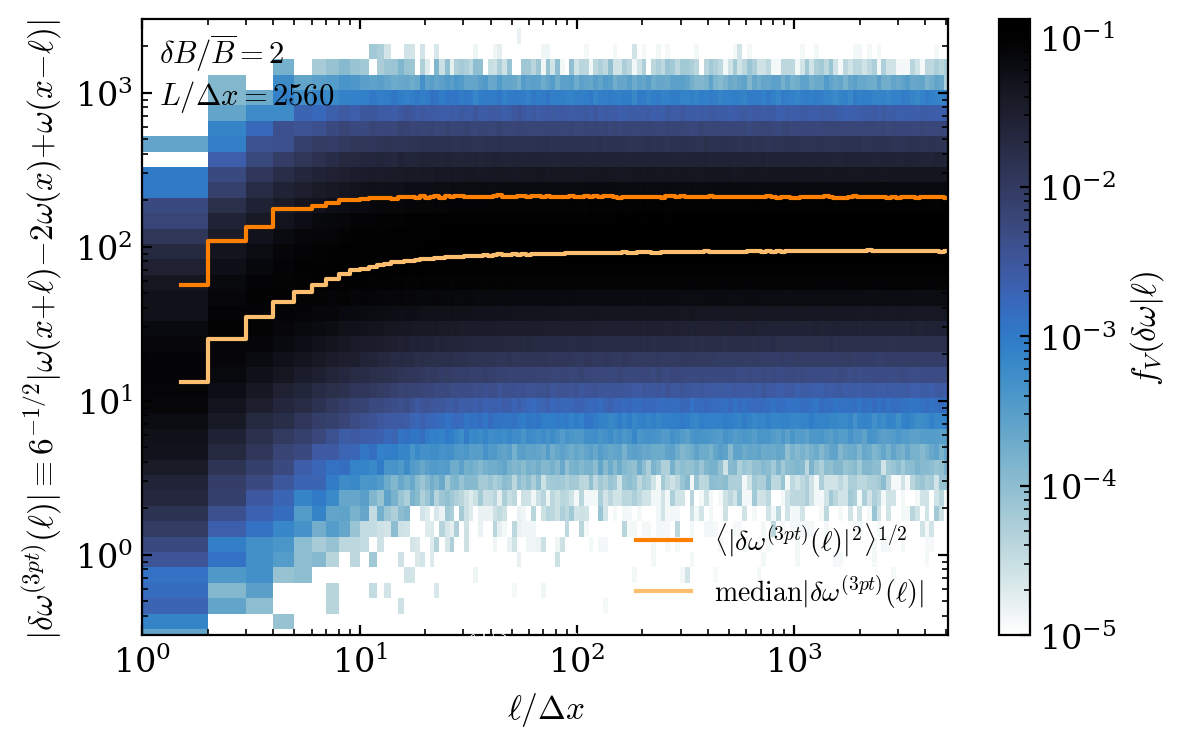

In [17]:
p_orders = np.arange(1,11,1)
rhosfp = np.array([ (np.sum(np.sum(hist_mag[6], axis=(1,2))*(sf_bin_centers/np.sqrt(6))**p, axis=1) / np.sum(hist_mag[6], axis=(1,2,3)))**(1/p) for p in p_orders])
rhosf_median = np.array([ np.interp(0.5, np.cumsum(np.sum(hist_mag[6], axis=(1,2))[i]) / np.sum(hist_mag[6], axis=(1,2,3))[i], (sf_bin_centers/np.sqrt(6))) for i in range(hist_mag[6].shape[0])])


fig, ax = plt.subplots(1, 1, figsize=(6.5, 4))
plot = ax.pcolormesh(ell_bin_centers, (sf_bin_centers/np.sqrt(6)), np.sum(hist_mag[6], axis=(1,2)).T/np.sum(np.sum(hist_mag[6], axis=(1,2)).T,axis=0), norm=LogNorm(vmin = 1e-5), cmap=cmr.arctic_r)
cb = fig.colorbar(plot)
cb.set_label(r"$f_V(\delta \omega|\ell)$")
ax.step(ell_bin_centers, rhosfp[2], color='#ff7f00', where='mid', label = r"$\langle |\delta \omega^{(3pt)}(\ell)|^{2} \rangle^{1/2}$")
ax.step(ell_bin_centers, rhosf_median, color='#fdbf6f', where='mid', label = r"${\rm median}|\delta \omega^{(3pt)}(\ell)|$")
# ax.grid(lw=0.5, ls=':')
# ax.axhline(1, color='#e31a1c', linestyle='--')
# ax.text(600, 1/1.15, r"$c_s$", color='#e31a1c', va='top', ha='right', fontsize=10)

line_color = 'white'
x_line = ell_bin_centers[20:]
y_line = 4*B0*(x_line/ell_bin_centers[-1])**(1/3)
ax.loglog(x_line, y_line, color=line_color, lw=0.5, ls=':')
# Add label just above the left edge of the line
ax.text(x_line[0], y_line[0]*1.15, r"$\propto \ell^{1/3}$", color=line_color, va='bottom', ha='left', fontsize=10)

ax.set_ylabel(r'$|\delta \omega^{(3pt)}(\ell)| \equiv 6^{-1/2}|\omega(x{+}\ell) {-} 2\omega(x) {+} \omega(x{-}\ell)|$', loc='top')
ax.set_xlabel(r'$\ell / \Delta x$')
ax.set_ylim(3e-1, 3e3)
ax.legend(loc='lower right', fontsize=10, frameon=False)

ax.text(
    0.02, 0.98,
    r"$\delta B / \overline{B} = 2$"+"\n"+r"$L/\Delta x = 2560$",
    transform=ax.transAxes,
    va='top',
    ha='left',
    fontsize=11,
    color='black'
)


Text(0.02, 0.98, '$\\delta B / \\overline{B} = 2$\n$L/\\Delta x = 2560$')

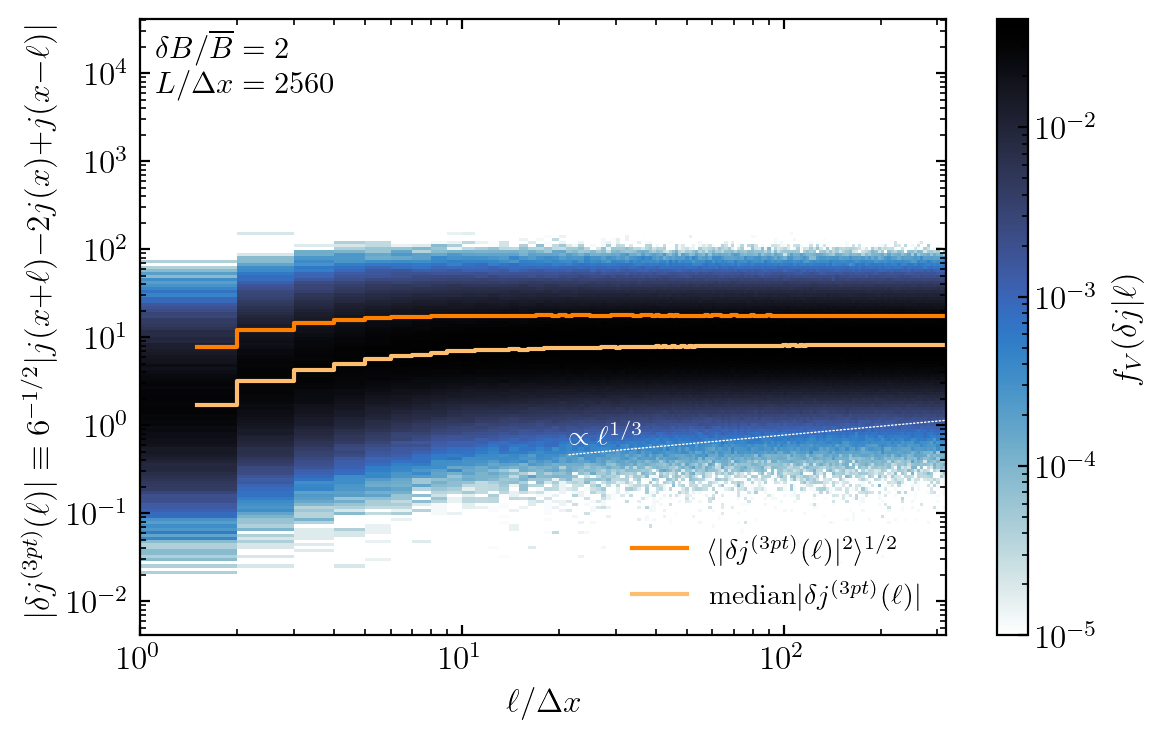

In [ ]:
p_orders = np.arange(1,11,1)
rhosfp = np.array([ (np.sum(np.sum(hist_mag[7], axis=(1,2))*(sf_bin_centers/np.sqrt(6))**p, axis=1) / np.sum(hist_mag[7], axis=(1,2,3)))**(1/p) for p in p_orders])
rhosf_median = np.array([ np.interp(0.5, np.cumsum(np.sum(hist_mag[7], axis=(1,2))[i]) / np.sum(hist_mag[7], axis=(1,2,3))[i], (sf_bin_centers/np.sqrt(6))) for i in range(hist_mag[7].shape[0])])


fig, ax = plt.subplots(1, 1, figsize=(6.5, 4))
plot = ax.pcolormesh(ell_bin_centers, (sf_bin_centers/np.sqrt(6)), np.sum(hist_mag[7], axis=(1,2)).T/np.sum(np.sum(hist_mag[7], axis=(1,2)).T,axis=0), norm=LogNorm(vmin = 1e-5), cmap=cmr.arctic_r)
cb = fig.colorbar(plot)
cb.set_label(r"$f_V(\delta j|\ell)$")
ax.step(ell_bin_centers, rhosfp[2], color='#ff7f00', where='mid', label = r"$\langle |\delta j^{(3pt)}(\ell)|^{2} \rangle^{1/2}$")
ax.step(ell_bin_centers, rhosf_median, color='#fdbf6f', where='mid', label = r"${\rm median}|\delta j^{(3pt)}(\ell)|$")
# ax.grid(lw=0.5, ls=':')
# ax.axhline(1, color='#e31a1c', linestyle='--')
# ax.text(600, 1/1.15, r"$c_s$", color='#e31a1c', va='top', ha='right', fontsize=10)

line_color = 'white'
x_line = ell_bin_centers[20:]
y_line = 4*B0*(x_line/ell_bin_centers[-1])**(1/3)
ax.loglog(x_line, y_line, color=line_color, lw=0.5, ls=':')
# Add label just above the left edge of the line
ax.text(x_line[0], y_line[0]*1.15, r"$\propto \ell^{1/3}$", color=line_color, va='bottom', ha='left', fontsize=10)

ax.set_ylabel(r'$|\delta j^{(3pt)}(\ell)| \equiv 6^{-1/2}|j(x{+}\ell) {-} 2j(x) {+} j(x{-}\ell)|$', loc='top')
ax.set_xlabel(r'$\ell / \Delta x$')
ax.set_ylim(3e-1, 3e3)
ax.legend(loc='lower right', fontsize=10, frameon=False)

ax.text(
    0.02, 0.98,
    r"$\delta B / \overline{B} = 2$"+"\n"+r"$L/\Delta x = 2560$",
    transform=ax.transAxes,
    va='top',
    ha='left',
    fontsize=11,
    color='black'
)


Text(0.02, 0.98, '$\\delta B / \\overline{B} = 2$\n$L/\\Delta x = 2560$')

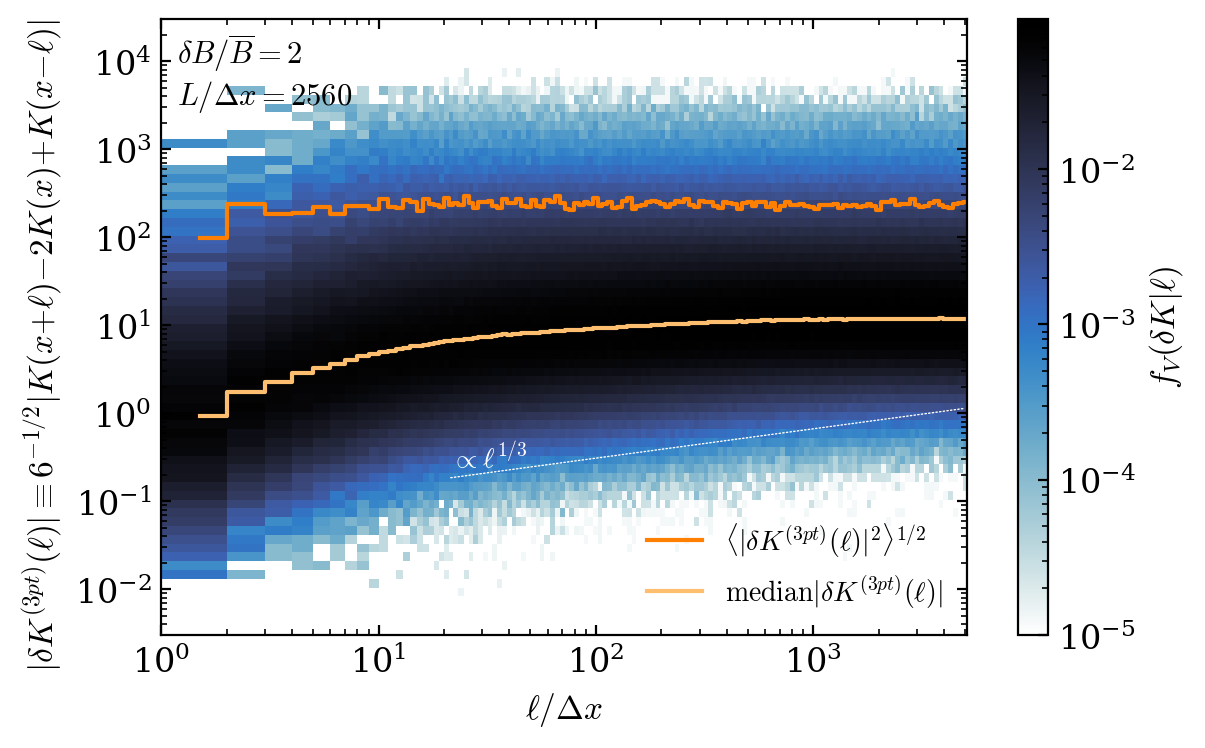

In [21]:
p_orders = np.arange(1,11,1)
rhosfp = np.array([ (np.sum(np.sum(hist_mag[8], axis=(1,2))*(sf_bin_centers/np.sqrt(6))**p, axis=1) / np.sum(hist_mag[8], axis=(1,2,3)))**(1/p) for p in p_orders])
rhosf_median = np.array([ np.interp(0.5, np.cumsum(np.sum(hist_mag[8], axis=(1,2))[i]) / np.sum(hist_mag[8], axis=(1,2,3))[i], (sf_bin_centers/np.sqrt(6))) for i in range(hist_mag[8].shape[0])])


fig, ax = plt.subplots(1, 1, figsize=(6.5, 4))
plot = ax.pcolormesh(ell_bin_centers, (sf_bin_centers/np.sqrt(6)), np.sum(hist_mag[8], axis=(1,2)).T/np.sum(np.sum(hist_mag[8], axis=(1,2)).T,axis=0), norm=LogNorm(vmin = 1e-5), cmap=cmr.arctic_r)
cb = fig.colorbar(plot)
cb.set_label(r"$f_V(\delta K|\ell)$")
ax.step(ell_bin_centers, rhosfp[2], color='#ff7f00', where='mid', label = r"$\langle |\delta K^{(3pt)}(\ell)|^{2} \rangle^{1/2}$")
ax.step(ell_bin_centers, rhosf_median, color='#fdbf6f', where='mid', label = r"${\rm median}|\delta K^{(3pt)}(\ell)|$")
# ax.grid(lw=0.5, ls=':')
# ax.axhline(1, color='#e31a1c', linestyle='--')
# ax.text(600, 1/1.15, r"$c_s$", color='#e31a1c', va='top', ha='right', fontsize=10)

line_color = 'white'
x_line = ell_bin_centers[20:]
y_line = 4*B0*(x_line/ell_bin_centers[-1])**(1/3)
ax.loglog(x_line, y_line, color=line_color, lw=0.5, ls=':')
# Add label just above the left edge of the line
ax.text(x_line[0], y_line[0]*1.15, r"$\propto \ell^{1/3}$", color=line_color, va='bottom', ha='left', fontsize=10)

ax.set_ylabel(r'$|\delta K^{(3pt)}(\ell)| \equiv 6^{-1/2}|K(x{+}\ell) {-} 2K(x) {+} K(x{-}\ell)|$', loc='top')
ax.set_xlabel(r'$\ell / \Delta x$')
ax.set_ylim(3e-3, 3e4)
ax.legend(loc='lower right', fontsize=10, frameon=False)

ax.text(
    0.02, 0.98,
    r"$\delta B / \overline{B} = 2$"+"\n"+r"$L/\Delta x = 2560$",
    transform=ax.transAxes,
    va='top',
    ha='left',
    fontsize=11,
    color='black'
)


Text(0.02, 0.98, '$\\delta B / \\overline{B} = 2$\n$L/\\Delta x = 2560$')

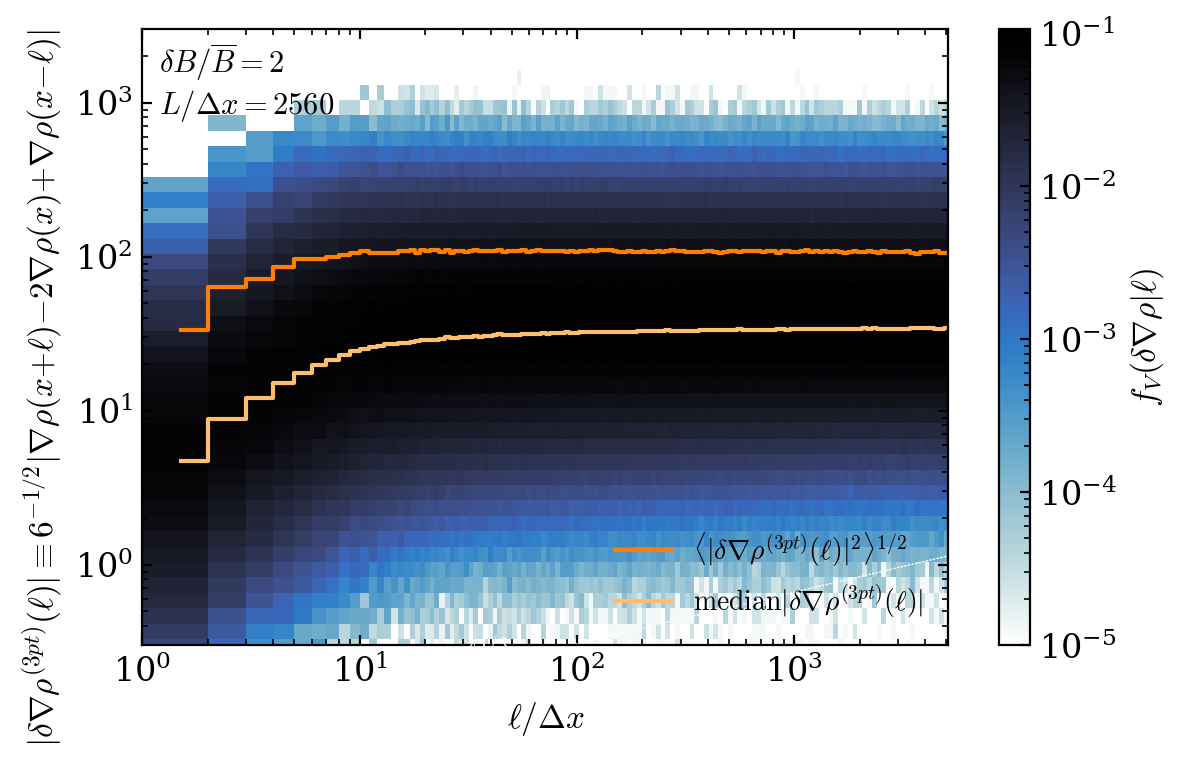

In [22]:
p_orders = np.arange(1,11,1)
rhosfp = np.array([ (np.sum(np.sum(hist_mag[9], axis=(1,2))*(sf_bin_centers/np.sqrt(6))**p, axis=1) / np.sum(hist_mag[9], axis=(1,2,3)))**(1/p) for p in p_orders])
rhosf_median = np.array([ np.interp(0.5, np.cumsum(np.sum(hist_mag[9], axis=(1,2))[i]) / np.sum(hist_mag[9], axis=(1,2,3))[i], (sf_bin_centers/np.sqrt(6))) for i in range(hist_mag[9].shape[0])])


fig, ax = plt.subplots(1, 1, figsize=(6.5, 4))
plot = ax.pcolormesh(ell_bin_centers, (sf_bin_centers/np.sqrt(6)), np.sum(hist_mag[9], axis=(1,2)).T/np.sum(np.sum(hist_mag[9], axis=(1,2)).T,axis=0), norm=LogNorm(vmin = 1e-5), cmap=cmr.arctic_r)
cb = fig.colorbar(plot)
cb.set_label(r"$f_V(\delta \nabla \rho|\ell)$")
ax.step(ell_bin_centers, rhosfp[2], color='#ff7f00', where='mid', label = r"$\langle |\delta \nabla \rho^{(3pt)}(\ell)|^{2} \rangle^{1/2}$")
ax.step(ell_bin_centers, rhosf_median, color='#fdbf6f', where='mid', label = r"${\rm median}|\delta \nabla \rho^{(3pt)}(\ell)|$")
# ax.grid(lw=0.5, ls=':')
# ax.axhline(1, color='#e31a1c', linestyle='--')
# ax.text(600, 1/1.15, r"$c_s$", color='#e31a1c', va='top', ha='right', fontsize=10)

line_color = 'white'
x_line = ell_bin_centers[20:]
y_line = 4*B0*(x_line/ell_bin_centers[-1])**(1/3)
ax.loglog(x_line, y_line, color=line_color, lw=0.5, ls=':')
# Add label just above the left edge of the line
ax.text(x_line[0], y_line[0]*1.15, r"$\propto \ell^{1/3}$", color=line_color, va='bottom', ha='left', fontsize=10)

ax.set_ylabel(r'$|\delta \nabla \rho^{(3pt)}(\ell)| \equiv 6^{-1/2}|\nabla \rho(x{+}\ell) {-} 2\nabla \rho(x) {+} \nabla \rho(x{-}\ell)|$', loc='top')
ax.set_xlabel(r'$\ell / \Delta x$')
ax.set_ylim(3e-1, 3e3)
ax.legend(loc='lower right', fontsize=10, frameon=False)

ax.text(
    0.02, 0.98,
    r"$\delta B / \overline{B} = 2$"+"\n"+r"$L/\Delta x = 2560$",
    transform=ax.transAxes,
    va='top',
    ha='left',
    fontsize=11,
    color='black'
)


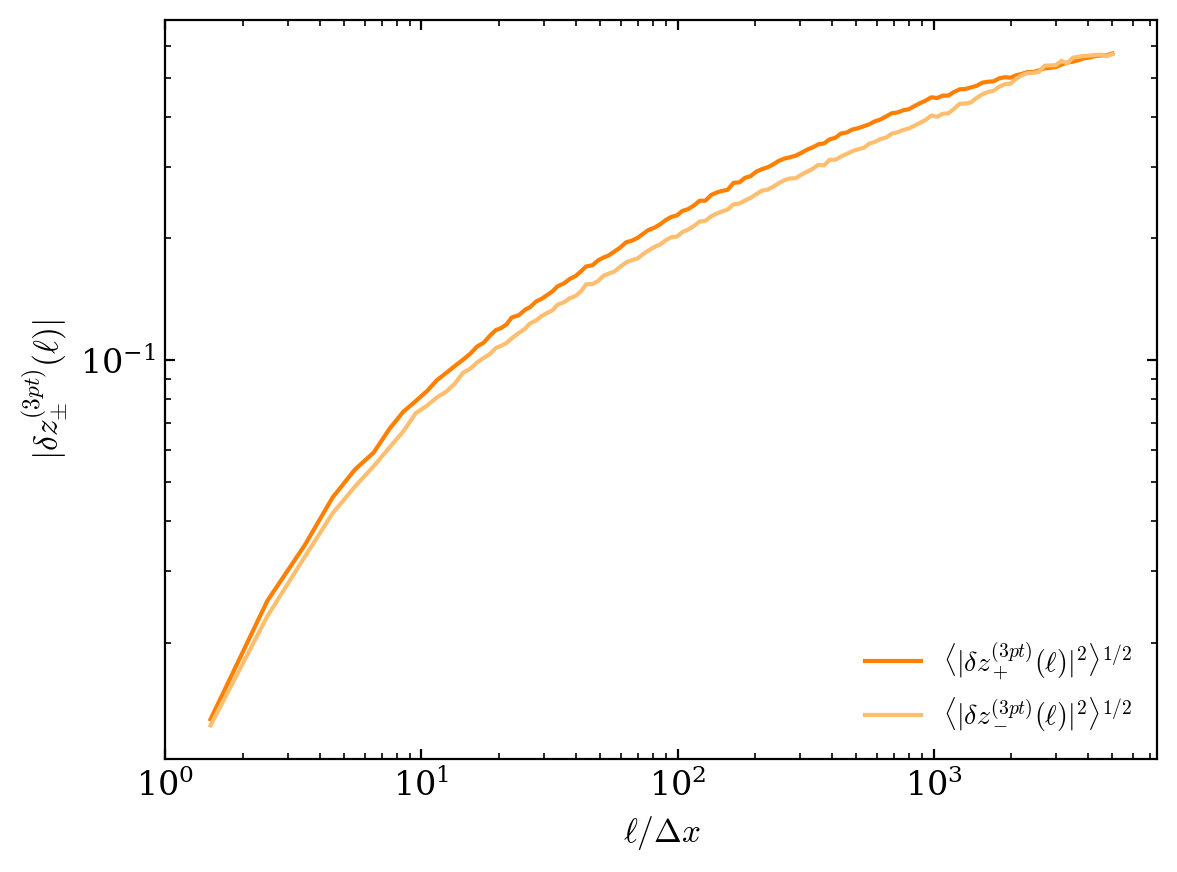

In [ ]:
p = 2
zplus_SF = (np.sum(np.sum(hist_mag[4], axis=(1,2))*(sf_bin_centers/np.sqrt(6))**p, axis=1) / np.sum(hist_mag[4], axis=(1,2,3)))**(1/p)
zminus_SF = (np.sum(np.sum(hist_mag[5], axis=(1,2))*(sf_bin_centers/np.sqrt(6))**p, axis=1) / np.sum(hist_mag[5], axis=(1,2,3)))**(1/p)

plt.loglog(ell_bin_centers, zplus_SF, color='#ff7f00', label = r"$\langle |\delta z_+^{(3pt)}(\ell)|^{2} \rangle^{1/2}$")
plt.loglog(ell_bin_centers, zminus_SF, color='#fdbf6f', label = r"$\langle |\delta z_-^{(3pt)}(\ell)|^{2} \rangle^{1/2}$")
plt.legend(loc='lower right', fontsize=10, frameon=False)
plt.xlabel(r'$\ell / \Delta x$')
plt.ylabel(r'$|\delta z_{\pm}^{(3pt)}(\ell)|$')
plt.show()

In [15]:
theta_Vperp_Bperp = hist_other[0]/hist_other[4]

/tmp/ipykernel_3199665/1299485050.py:1: RuntimeWarning: divide by zero encountered in divide
  theta_Vperp_Bperp = hist_other[0]/hist_other[4]
/tmp/ipykernel_3199665/1299485050.py:1: RuntimeWarning: invalid value encountered in divide
  theta_Vperp_Bperp = hist_other[0]/hist_other[4]


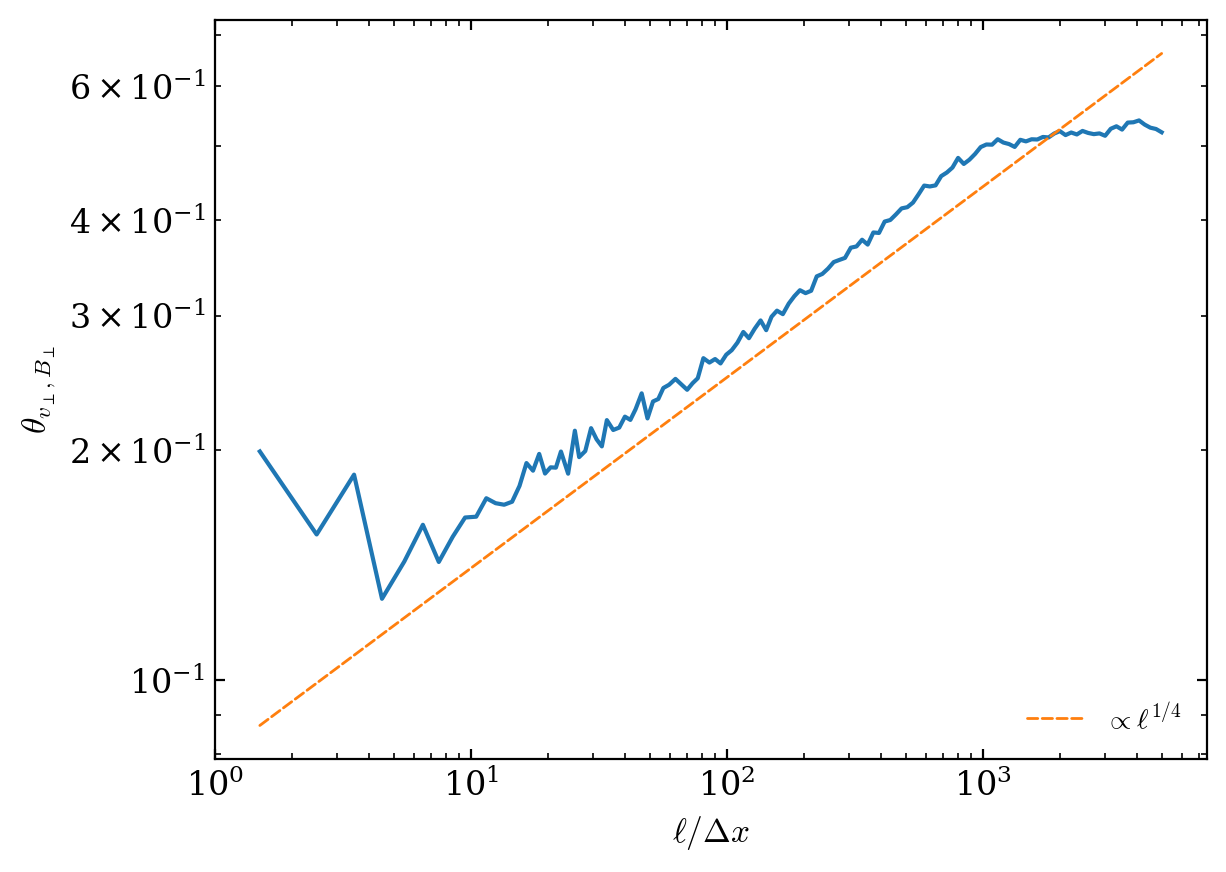

In [16]:
p = 2
Vperp_CROSS_Bperp_SF = (np.sum(hist_other[0]*(product_bin_centers/np.sqrt(6))**p, axis=1) / np.sum(hist_other[0], axis=(-1)))**(1/p)
Vperp_Bperp_MAG_SF = (np.sum(hist_other[4]*(product_bin_centers/np.sqrt(6))**p, axis=1) / np.sum(hist_other[4], axis=(-1)))**(1/p)
theta_Vperp_Bperp = Vperp_CROSS_Bperp_SF/Vperp_Bperp_MAG_SF
plt.loglog(ell_bin_centers, theta_Vperp_Bperp)
plt.loglog(ell_bin_centers, theta_Vperp_Bperp[-20]*(ell_bin_centers/ell_bin_centers[-20])**(1/4), ls='--', lw=1, label=r"$\propto \ell^{1/4}$")
plt.legend(loc='lower right', fontsize=10, frameon=False)
plt.xlabel(r'$\ell / \Delta x$')
plt.ylabel(r'$\theta_{v_{\perp}, B_{\perp}}$')
plt.show()

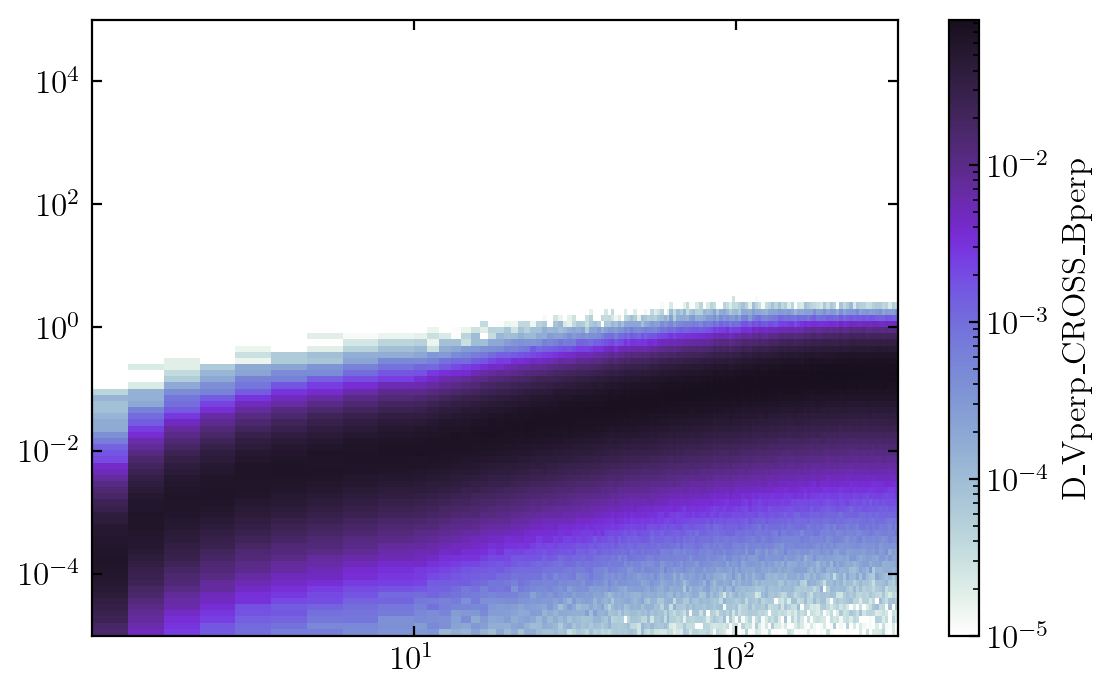

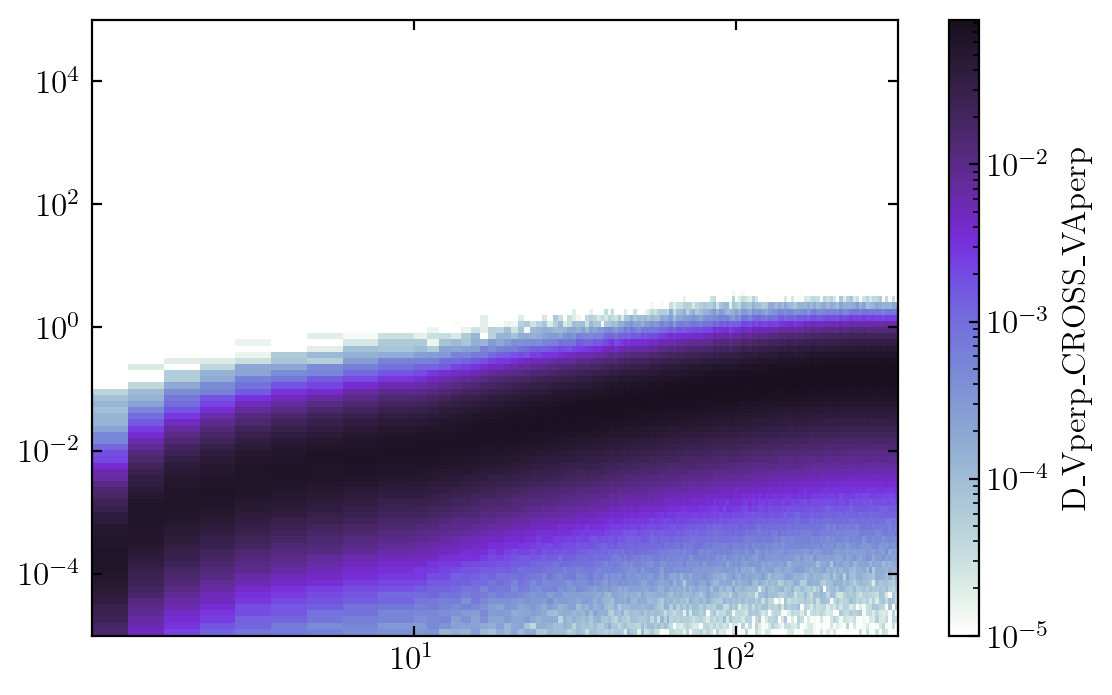

In [34]:
for i in range(2):#len(other_channels)):
    fig, ax = plt.subplots(1, 1, figsize=(6.5, 4))
    plot = ax.pcolormesh(ell_bin_centers, product_bin_centers, hist_other[i].T/np.sum(hist_other[i].T,axis=0), norm=LogNorm(vmin = 1e-5), cmap=cmr.get_sub_cmap('cmr.amethyst_r',0, 0.9))
    ax.set_yscale('log')
    ax.set_xscale('symlog', linthresh=1e1)
    cb = fig.colorbar(plot)
    cb.set_label(other_channels[i])
    plt.show()

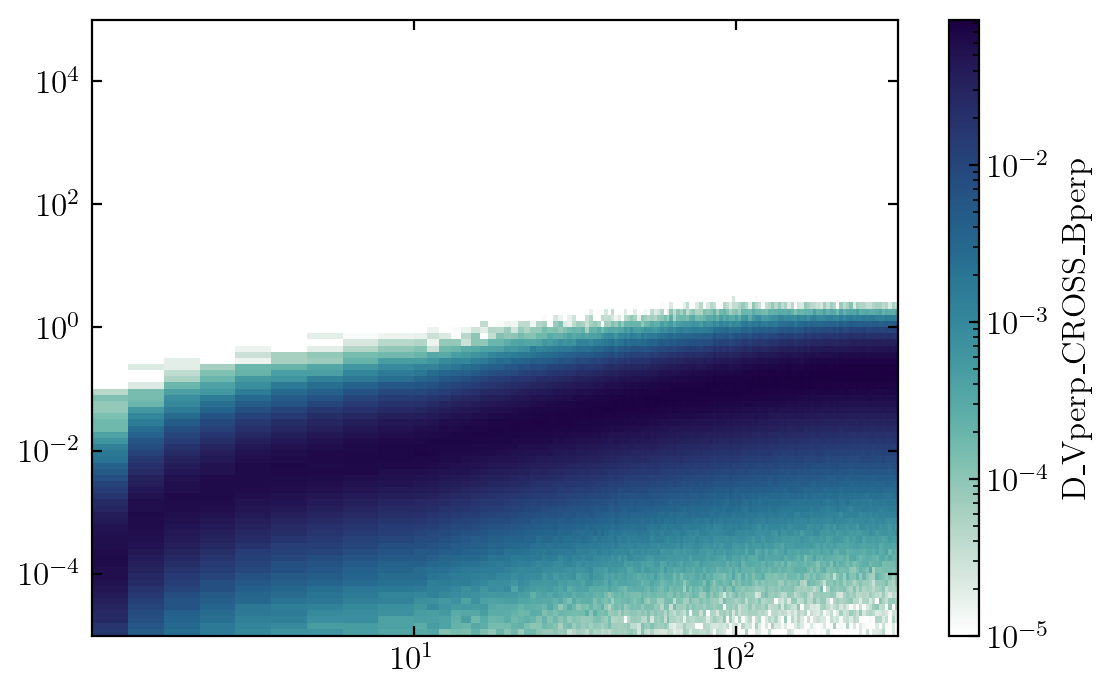

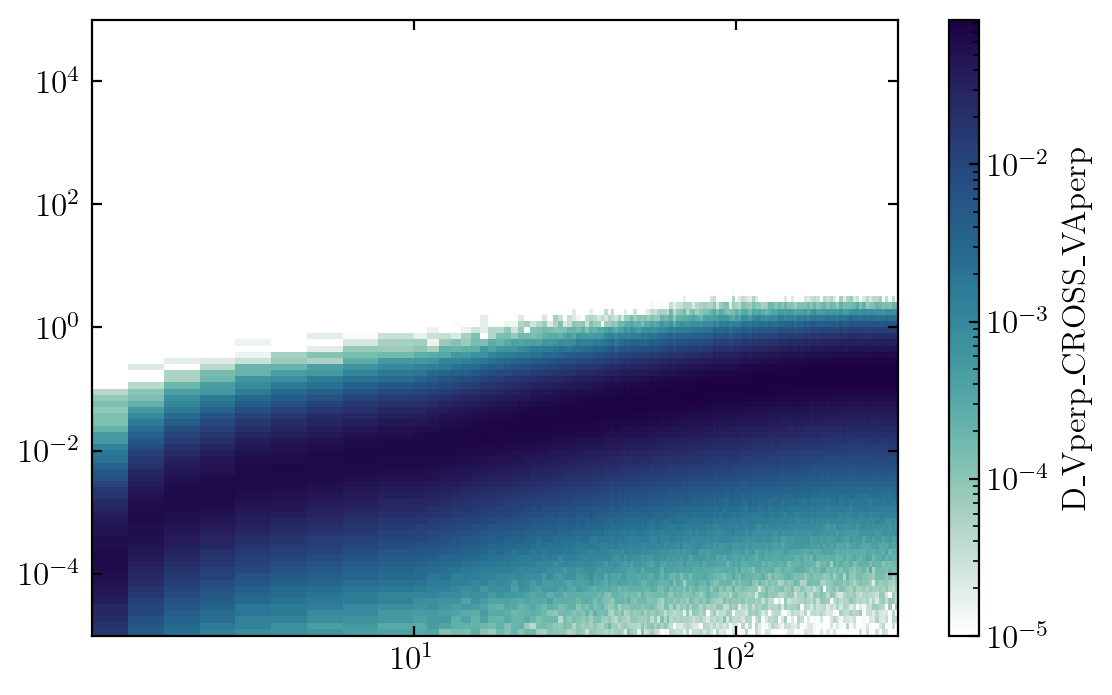

In [37]:
for i in range(2):#len(other_channels)):
    fig, ax = plt.subplots(1, 1, figsize=(6.5, 4))
    plot = ax.pcolormesh(ell_bin_centers, product_bin_centers, hist_other[i].T/np.sum(hist_other[i].T,axis=0), norm=LogNorm(vmin = 1e-5), cmap=cmr.get_sub_cmap('cmr.ocean_r',0, 1))
    ax.set_yscale('log')
    ax.set_xscale('symlog', linthresh=1e1)
    cb = fig.colorbar(plot)
    cb.set_label(other_channels[i])
    plt.show()